## XMAC02 - Atividade Avaliativa 1
### Nome:
### Nro Matric:

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Nas questões de 1 a 4 você deve utilizar o dataset nba2k.csv.

In [2]:
df = pd.read_csv("nba2k.csv")
df.head()

,Unnamed: 0,full_name,rating,jersey,team,position,b_day,height,weight,salary,country,draft_year,draft_round,draft_peak,college,version
0,0,LeBron James,97,#23,Los Angeles Lakers,F,12/30/84,2.06,113.4,37436858,USA,2003,1,1,NaN,NBA2k20
1,1,Kawhi Leonard,97,#2,Los Angeles Clippers,F,06/29/91,2.01,102.1,32742000,USA,2011,1,15,San Diego State,NBA2k20
2,2,Giannis Antetokounmpo,96,#34,Milwaukee Bucks,F-G,12/06/94,2.11,109.8,25842697,Greece,2013,1,15,NaN,NBA2k20
3,3,Kevin Durant,96,#7,Brooklyn Nets,F,09/29/88,2.08,104.3,37199000,USA,2007,1,2,Texas,NBA2k20
4,4,James Harden,96,#13,Houston Rockets,G,08/26/89,1.96,99.8,38199000,USA,2009,1,3,Arizona State,NBA2k20


Formato dos arquivos CSV utilizados:

```
day.csv

instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985

nba2k.csv
,full_name,rating,jersey,team,position,b_day,height,weight,salary,country,draft_year,draft_round,draft_peak,college,version
0,LeBron James,97,#23,Los Angeles Lakers,F,12/30/84,2.06,113.4,37436858,USA,2003,1,1,,NBA2k20


student-por.csv

school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
"GP";"F";18;"U";"GT3";"A";4;4;"at_home";"teacher";"course";"mother";2;2;0;"yes";"no";"no";"no";"yes";"yes";"no";"no";4;3;4;1;1;3;4;"0";"11";11
```

### Questão 1 [valor: 0,5 pt]
Obtenha a média, o desvio padrão e a mediana da altura dos armadores (position = G) estrangeiros da NBA, ou seja, dos jogadores que jogam na posição de armador e que tenham country diferente de USA.

In [3]:
armadores_estrangeiros = df[(df['position'] == 'G') & (df['country'] != 'USA')]['height']

print(f"Média:         {armadores_estrangeiros.mean():.3f} m")
print(f"Desvio padrão: {armadores_estrangeiros.std():.3f} m")
print(f"Mediana:       {armadores_estrangeiros.median():.3f} m")

Média:         1.928 m
Desvio padrão: 0.058 m
Mediana:       1.930 m


### Questão 2 [valor: 1,0 pt]
Gere um gráfico contendo dois boxplots comparando o salário dos jogoadores do Los Angeles Lakers e do Utah Jazz.

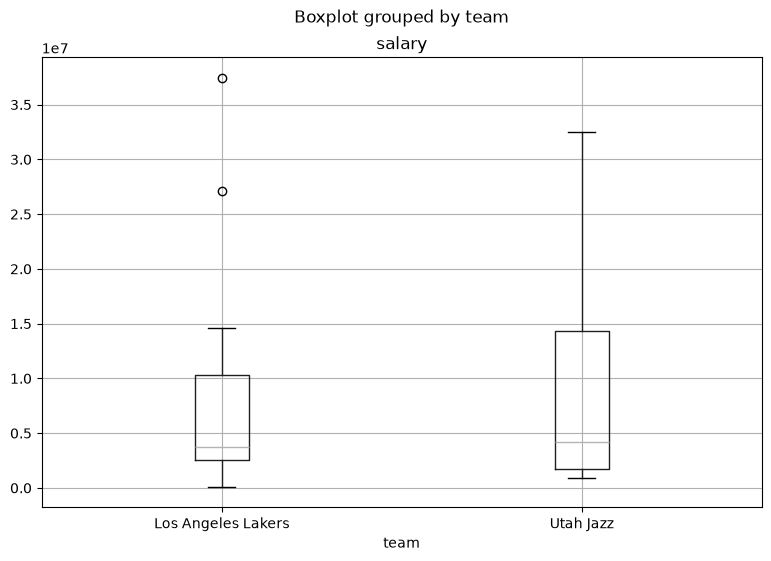

In [4]:
times = ['Los Angeles Lakers', 'Utah Jazz']
df_times = df[df['team'].isin(times)]

df_times.boxplot(column='salary', by='team', figsize=(9, 6))
plt.show()

### Questão 3 [valor: 1,5 pt]
Gere um gráfico que exiba o valor do salário dos 10 jogadores mais altos da NBA, organizados de ordem descendente, ou seja, do mais bem pago para o menos bem pago.

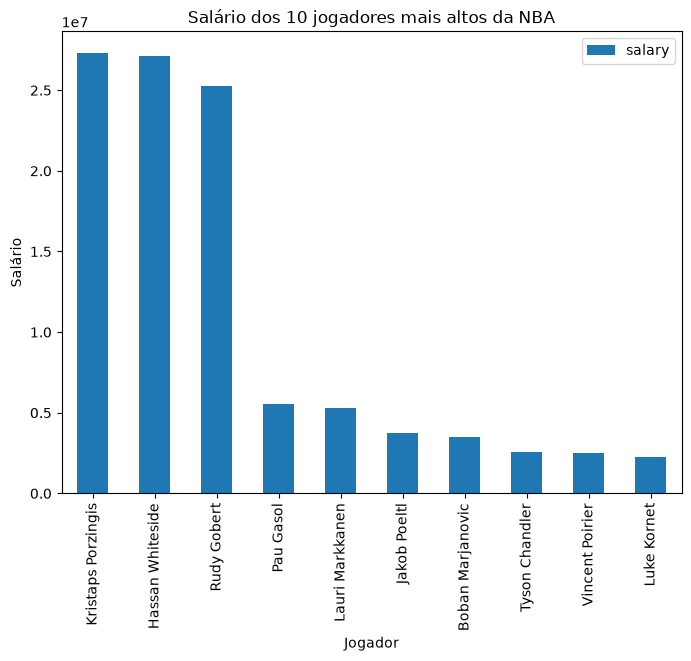

In [5]:
# 10 jogadores mais altos, ordenados do mais bem pago para o menos bem pago
top10_altos = (df.sort_values('height', ascending=False)
                 .head(10)
                 .sort_values('salary', ascending=False))

top10_altos.plot(kind='bar', x='full_name', y='salary', figsize=(8, 6))
plt.title('Salário dos 10 jogadores mais altos da NBA')
plt.xlabel('Jogador')
plt.ylabel('Salário')
plt.show()

### Questão 4 [valor: 2,0 pts]
Gere dois gráficos de pizza lado a lado que exibam: \
A) o percentual de jogadores americanos vs jogadores estrangeiros na NBA; \
B) o valor total pago a jogadores americanos vs jogadores estrangeiros na NBA.

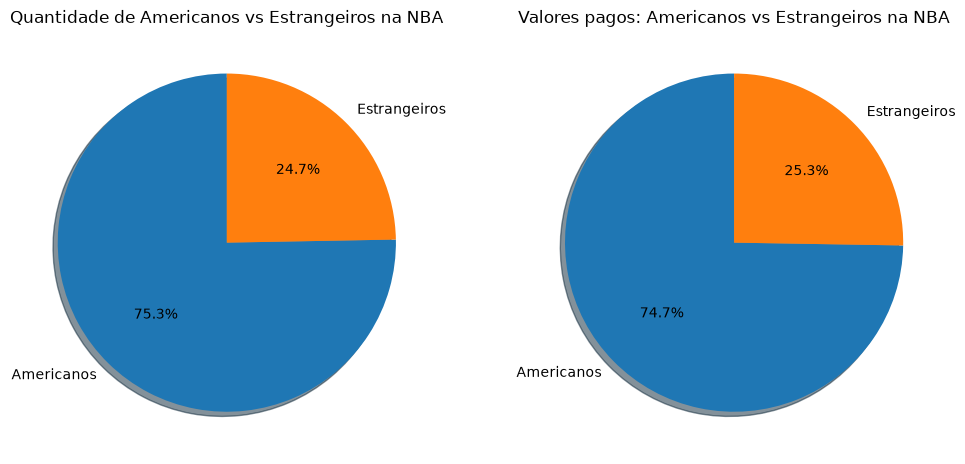

In [12]:
americanos = df[df['country'] == 'USA']
estrangeiros = df[df['country'] != 'USA']

qtd = [len(americanos), len(estrangeiros)]

total_pago = [
    americanos['salary'].sum(),
    estrangeiros['salary'].sum()
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(
    qtd,
    labels=['Americanos', 'Estrangeiros'],
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

axes[0].set_title('Quantidade de Americanos vs Estrangeiros na NBA')

axes[1].pie(
    total_pago,
    labels=['Americanos', 'Estrangeiros'],
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

axes[1].set_title('Valores pagos: Americanos vs Estrangeiros na NBA')

plt.show()

______________

Nas questões 5 a 8 deve-se usar os dataframes a seguir.

In [7]:
bike_day = pd.read_csv('day.csv')
students = pd.read_csv('student-por.csv', sep=';')

print('Bike — dados diários:', bike_day.shape)
print('Desempenho estudantil:', students.shape)

Bike — dados diários: (731, 16)
Desempenho estudantil: (649, 33)


### Questão 5 [valor: 1,5]

Utilize o DataFrame `bike_day`. Plote um gráfico de barras que mostre a média diária de locações de bike por estação. Substitua os códigos numéricos pelos nomes **Primavera**, **Verão**, **Outono** e **Inverno**

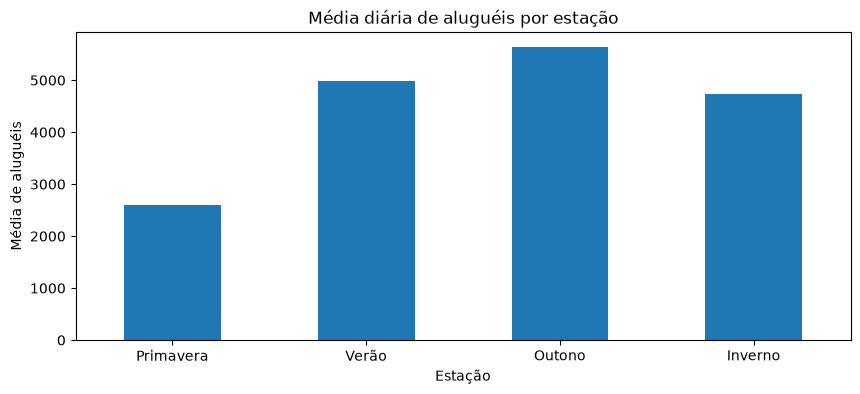

In [8]:
nomes_estacoes = {1: 'Primavera', 2: 'Verão', 3: 'Outono', 4: 'Inverno'}

media_estacao = bike_day.groupby('season')['cnt'].mean()
media_estacao.index = media_estacao.index.map(nomes_estacoes)

media_estacao.plot(kind='bar', rot=0, figsize=(10, 4))
plt.title('Média diária de aluguéis por estação')
plt.xlabel('Estação')
plt.ylabel('Média de aluguéis')
plt.show()

### Questão 6 [valor: 1,0]

Utilize o DataFrame `students`.

1. Agrupe os estudantes pela categoria de tempo semanal de estudo (`studytime`).
2. Para cada categoria, obtenha:
   - a quantidade de estudantes;
   - a média da nota final (`G3`);
3. Armazene as duas medidas em um novo DataFrame com nomes de colunas claros.
4. Construa um **gráfico de linha** da média de `G3` em função da categoria de tempo de estudo.

           qtd_estudantes   media_G3
studytime                           
1                     212  10.844340
2                     305  12.091803
3                      97  13.226804
4                      35  13.057143


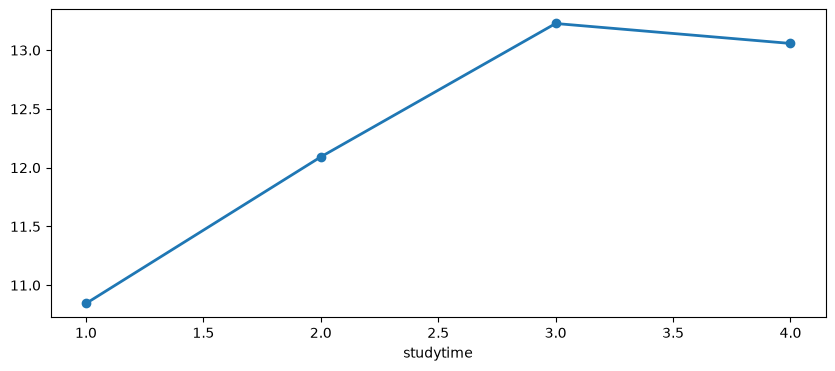

In [9]:
resumo_estudo = (students.groupby('studytime')
                         .agg(qtd_estudantes=('G3', 'count'),
                              media_G3=('G3', 'mean')))
print(resumo_estudo)

resumo_estudo['media_G3'].plot(kind='line', marker='o', linewidth=2, figsize=(10, 4))
plt.xlabel('studytime')
plt.show()

### Questão 7 [valor: 1,0]

Utilize o DataFrame `students`. Construa um gráfico de barras agrupado por sexo que mostre a quantidade de alunos com e sem Internet em casa.

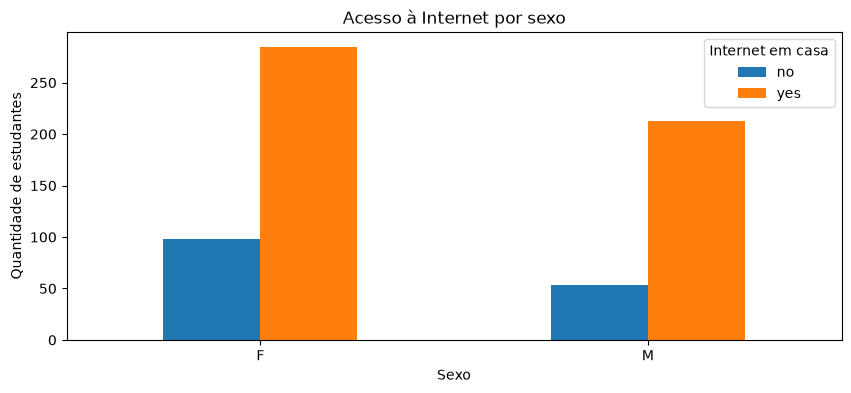

In [14]:
internet_sexo = pd.crosstab(students['sex'], students['internet'])

internet_sexo.plot(kind='bar', rot=0, figsize=(10, 4))
plt.title('Acesso à Internet por sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade de estudantes')
plt.legend(title='Internet em casa')
plt.show()

## Questão 8 [valor: 1,5]

Utilize o DataFrame `students`.

1. Investigue a relação entre tempo semanal de estudo (`studytime`) e intenção de cursar o ensino superior (`higher`).
2. Construa uma tabela de contingência **normalizada por linha**: cada linha deverá mostrar as proporções de respostas `yes` e `no` dentro daquela categoria de tempo de estudo.
3. Exiba os valores como percentuais, arredondados para uma casa decimal.
4. Construa um **gráfico de barras empilhadas**.
5. Escreva uma interpretação breve dos resultados.

higher       no   yes
studytime            
1          20.8  79.2
2           6.2  93.8
3           4.1  95.9
4           5.7  94.3


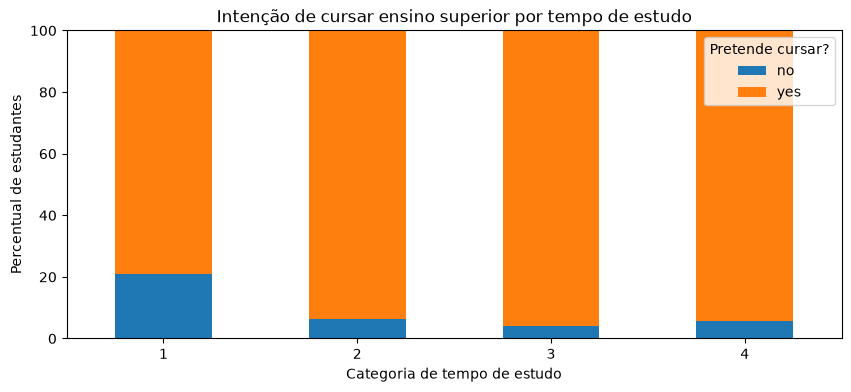

In [11]:
# Tabela de contingência normalizada por linha (em %)
tabela = (pd.crosstab(students['studytime'], students['higher'], normalize='index') * 100).round(1)
print(tabela)

tabela.plot(kind='bar', stacked=True, rot=0, figsize=(10, 4))
plt.title('Intenção de cursar ensino superior por tempo de estudo')
plt.xlabel('Categoria de tempo de estudo')
plt.ylabel('Percentual de estudantes')
plt.ylim(0, 100)
plt.legend(title='Pretende cursar?')
plt.show()

**Interpretação:** a grande maioria dos estudantes, em todas as categorias de tempo de estudo, pretende cursar o ensino superior (`yes`). Porém, entre os que estudam menos (categoria 1, menos de 2 h por semana), a proporção de respostas `no` é bem maior: cerca de 21%. Já nas categorias 2, 3 e 4 essa proporção cai para algo entre 4% e 6%, e a categoria 3 tem o menor percentual de `no`. Ou seja, há uma associação entre dedicar mais tempo aos estudos e ter intenção de seguir para o ensino superior, mas ela não é estritamente crescente (a categoria 4 tem um pouco mais de `no` que a 3). Trata-se de uma associação, não prova de causalidade.